## Imports and parameters

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pathlib import Path
from scipy.integrate import solve_ivp, quad, simpson
from scipy.special import gamma

N_VALUES = [100, 500, 1000, 5000]
DATA_DIR = Path("data")
RESULTS_FILE = DATA_DIR / "rplt_data.hdf5"
ALPHA = np.pi / 2
SYMMETRY_TOLERANCE = 0.05
R_MAX = 30.0
INITIAL_POINT = [0.0, 0.0]

## Computing the hitting radius $r^*$

 `rplt_data.hdf5` already exists, so this cell can be skipped. The Gaussian disk sector expansion files are not directly included in this repo due to their size, but can be requested.

In [ ]:
def evaluate_polynomial(z, coefficients):
    """
    Evaluate a polynomial with coefficients ordered from lowest to highest
    power.

    Returns
    -------
    complex
        Value of the polynomial at z
    """

    return np.polyval(coefficients[::-1], z)


def radial_preimage_ode(r, y, coefficients, alpha):
    """
    Differential equation for the preimage curve of a radial segment in
    the Gaussian disk.

    The curve gamma(r) satisfies

        gamma'(r) = exp(i alpha) / F'(gamma(r)).
    """

    z = y[0] + 1j * y[1]
    fprime = evaluate_polynomial(z, coefficients)

    if np.abs(fprime) < 1e-12:
        return [np.inf, np.inf]

    derivative = np.exp(1j * alpha) / fprime

    return [derivative.real, derivative.imag]


def hit_unit_circle(r, y, *args):
    """
    Detect when the preimage trajectory reaches the unit-circle boundary.

    Returns
    -------
    float
        Signed distance |gamma(r)| - 1 from the unit circle
    """

    return np.hypot(y[0], y[1]) - 1.0


def radial_distance(coefficients, alpha=ALPHA, r_max=R_MAX):
    """
    Compute the radial distance R for one Gaussian disk realization.

    The preimage curve is integrated from the origin until it reaches the
    unit circle. If the trajectory does not reach the boundary before
    r_max, NaN is returned.

    Returns
    -------
    float
        Radial distance R, or NaN if the unit circle is not reached
    """

    solution = solve_ivp(
        fun=radial_preimage_ode,
        t_span=(0.0, r_max),
        y0=INITIAL_POINT,
        events=hit_unit_circle,
        args=(coefficients, alpha)
    )

    if solution.status == 1 and len(solution.t_events[0]) > 0:
        return solution.t_events[0][0]

    return np.nan


def compute_radial_distances(N_values=N_VALUES, alpha=ALPHA):
    """
    Compute the radial distance R for all available Gaussian disk samples.

    Each input file is assumed to contain p, l and t in its first three
    columns, followed by the polynomial coefficients describing the sample.

    Returns
    -------
    dict
        Dictionary indexed by polynomial degree N containing columns
        (R, p, l, t)
    """

    results = {}

    for N in N_values:
        sample_file = DATA_DIR / f"samples_N{N}"

        raw_data = np.loadtxt(sample_file)
        boundary_data = raw_data[:, :3]
        coefficient_data = raw_data[:, 3:]

        radial_distances = np.array([radial_distance(coefficients, alpha) for coefficients in coefficient_data])

        results[N] = np.column_stack((radial_distances, boundary_data))
        n_success = np.sum(~np.isnan(radial_distances))
        print(f"Finished N = {N}: {n_success}/{len(radial_distances)} radial distances computed")

    return results


def save_radial_distances(results, filename=RESULTS_FILE, alpha=ALPHA):
    """
    Save the computed Gaussian disk observables to an HDF5 file.

    Each polynomial degree is stored in a separate group with columns
    (R, p, l, t).
    """

    with h5py.File(filename, "w") as f:
        f.attrs["alpha"] = alpha

        for N, values in results.items():
            dataset = f.create_dataset(f"{N}/data", data=values)
            dataset.attrs["columns"] = ["R", "p", "l", "t"]


hit_unit_circle.terminal = True
hit_unit_circle.direction = 1

results = compute_radial_distances()
save_radial_distances(results)

## Load the results

In [4]:
def load_gaussian_results(N, filename=RESULTS_FILE):
    """
    Load the Gaussian disk observables for one polynomial degree.

    Returns
    -------
    R, p, l, t : np arrays
    """

    with h5py.File(filename, "r") as f:
        R, p, l, t = f[f"{N}/data"][:].T

    return R, p, l, t

## Helper functions - Mellin transform

In [5]:
def pi_u_cot_pi_u(z):
    """
    Evaluate pi z cot(pi z), using its series expansion close to z = 0.

    Returns
    -------
    complex
        Value of pi z cot(pi z)
    """

    if np.abs(z) < 1e-8:
        return 1.0 - (np.pi * z) ** 2 / 3.0

    return np.pi * z / np.tan(np.pi * z)


def complex_quad(function, a, b, **kwargs):
    """
    Integrate a complex-valued function by separately integrating its real
    and imaginary parts.

    Returns
    -------
    complex
        Value of the complex integral
    """

    real_part = quad(lambda x: np.real(function(x)), a, b, **kwargs)[0]
    imaginary_part = quad(lambda x: np.imag(function(x)), a, b, **kwargs)[0]

    return real_part + 1j * imaginary_part


def mellin_Z_theta(s, theta):
    """
    Evaluate the Mellin transform of the sector scaling function Z^(theta).

    Returns
    -------
    complex
        Mellin transform evaluated at s
    """

    gamma_theta = -1.0 - theta / np.pi
    t = 0.5 + theta / (2.0 * np.pi)
    normalization = 2.0 * np.pi * 2.0 ** (theta / np.pi)

    integrand = lambda a: pi_u_cot_pi_u(-s + a)
    integral = complex_quad(integrand, -t, t, limit=200)

    prefactor = normalization / (gamma(1.0 - s + gamma_theta / 2.0) * gamma(1.0 + s + gamma_theta / 2.0))

    return prefactor * np.exp(-integral)


def Z_theta_from_mellin(x_values, theta, c=0.0, y_max=40.0, n_y=1201):
    """
    Numerically invert the Mellin transform to obtain the sector scaling
    function Z^(theta)(x).

    The inverse contour is truncated to imaginary parts between -y_max and
    y_max and evaluated using Simpson integration.

    Returns
    -------
    np.ndarray
        Numerical values of Z^(theta)(x)
    """

    x_values = np.asarray(x_values, dtype=float)
    y_values = np.linspace(-y_max, y_max, n_y)

    mellin_values = np.array([mellin_Z_theta(c + 1j * y, theta) for y in y_values], dtype=complex)

    Z_values = np.zeros_like(x_values)

    for i, x in enumerate(x_values):
        phase = np.exp(-1j * y_values * np.log(x))
        integrand = mellin_values * phase
        inverse = x ** (-c) * simpson(integrand, x=y_values) / (2.0 * np.pi)
        Z_values[i] = np.real(inverse)

    return Z_values

## Test one: expectation value radial cut length

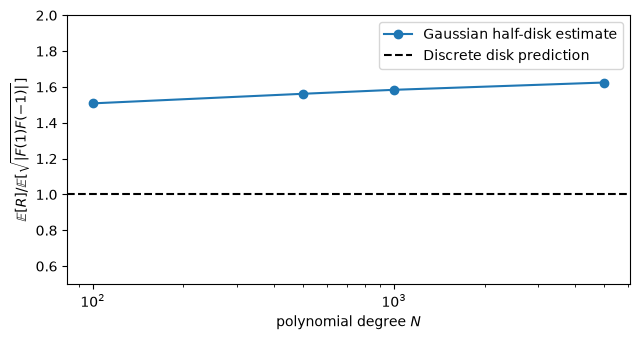

In [6]:
def expected_cut_ratio(N, filename=RESULTS_FILE):
    """
    Compute the ratio used in the expected radial-cut test,

        E[R] / E[sqrt(p l)].

    Samples for which R could not be determined are discarded.

    Returns
    -------
    float
        Numerical estimate of E[R] / E[sqrt(p l)]
    """

    R, p, l, _ = load_gaussian_results(N, filename)

    valid = ~np.isnan(R)

    R = R[valid]
    p = p[valid]
    l = l[valid]

    return np.mean(R) / np.mean(np.sqrt(p * l))

def plot_expected_cut_ratio(N_values=N_VALUES):
    """
    Plot the expected radial-cut ratio as a function of polynomial degree.
    """

    ratios = [expected_cut_ratio(N) for N in N_values]

    fig, ax = plt.subplots(figsize=(6.5, 3.5))

    ax.plot(N_values, ratios, "o-", label="Gaussian half-disk estimate")
    ax.axhline(1.0, color="k", linestyle="--", label="Discrete disk prediction")

    ax.set_xscale("log")
    ax.set_xlabel("polynomial degree $N$")
    ax.set_ylabel(r"$\mathbb{E}[R] / \mathbb{E}[\sqrt{|F(1)F(-1)|}]$")
    ax.set_ylim(0.5, 2.0)
    ax.legend()

    fig.tight_layout()
    plt.show()

plot_expected_cut_ratio()

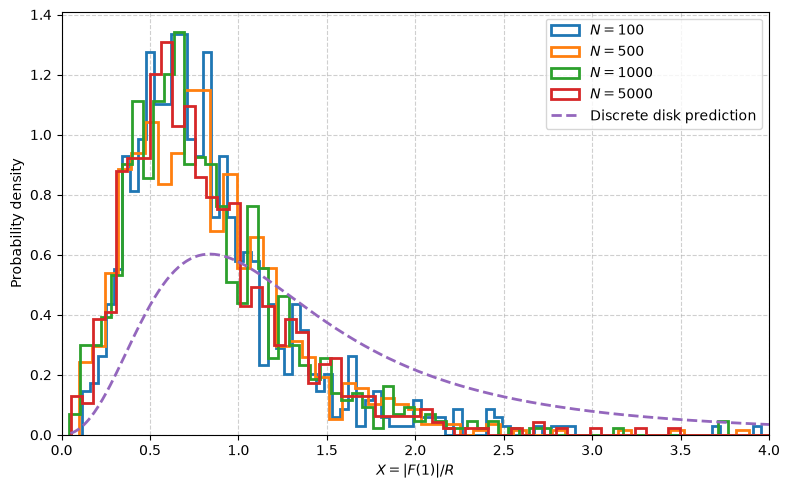

In [7]:
def boundary_ratio_samples(N, tolerance=SYMMETRY_TOLERANCE, filename=RESULTS_FILE):
    """
    Select approximately symmetric Gaussian disks and compute

        X = p / R.

    The approximate symmetry condition is

        |p - l| <= tolerance * l.

    Returns
    -------
    np.ndarray
        Accepted values of X = p / R
    """

    R, p, l, _ = load_gaussian_results(N, filename)

    symmetric = np.abs(p - l) <= tolerance * l
    valid = R > 1e-9

    mask = symmetric & valid

    return p[mask] / R[mask]


def predicted_ratio_density(x_values, theta=np.pi / 2, y_max=40.0, n_y=1201):
    """
    Compute the probability density predicted by the discrete disk model
    for the symmetric half-disk ratio.

    Returns
    -------
    np.ndarray
        Predicted probability density evaluated at x_values
    """

    Z_values = Z_theta_from_mellin(x_values, theta=theta, c=0.0, y_max=y_max, n_y=n_y)

    return 4.0 * np.pi * Z_values ** 2 / np.sqrt(x_values)

def plot_ratio_distribution(N_values=N_VALUES, tolerance=SYMMETRY_TOLERANCE):
    """
    Plot the empirical distributions of X = |F(1)| / R together with the
    discrete disk prediction.
    """

    x_values = np.linspace(0.05, 4.0, 350)
    theoretical_density = predicted_ratio_density(x_values)

    fig, ax = plt.subplots(figsize=(8, 5))

    for N in N_values:
        ratios = boundary_ratio_samples(N, tolerance)

        ax.hist(ratios, bins=100, density=True, histtype="step", lw=2, label=rf"$N = {N}$")

    ax.plot(x_values, theoretical_density, "--", lw=2, label="Discrete disk prediction")

    ax.set_xlabel(r"$X=|F(1)|/R$")
    ax.set_ylabel("Probability density")
    ax.set_xlim(0, 4)
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.6)

    fig.tight_layout()
    plt.show()

plot_ratio_distribution()

## Numerical evaluations in chapter 4

### Density function $$f_x(x) = 4\pi\frac{\bigl(\mathcal{Z}^{(\pi/2)}(x)\bigr)^2}{\sqrt{x}}, \qquad x>0,$$

Integral of f(x) = 1.0000000
E[x]             = 1.8027012
E[1/x]           = 1.0000000
Mass on [0, 4]   = 0.9332
Mode              = 0.838


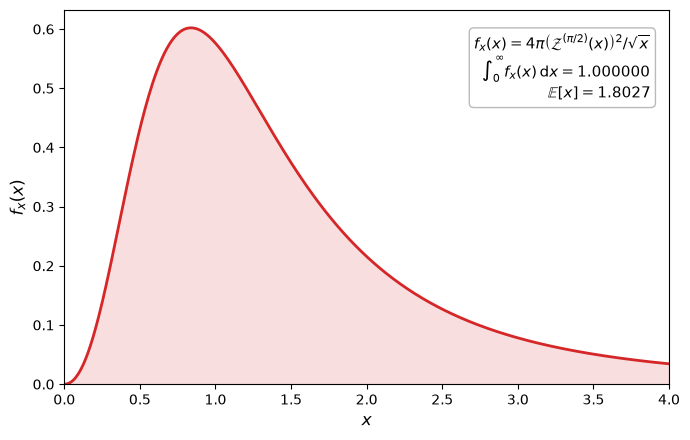

In [8]:
x_plot = np.linspace(0.005, 4.0, 500)
f_plot = predicted_ratio_density(x_plot, theta=np.pi / 2, y_max=80.0, n_y=2001)

# use a logarithmic grid to resolve both tails
x_tail = np.geomspace(1e-4, 1e4, 4001)
f_tail = predicted_ratio_density(x_tail, theta=np.pi / 2, y_max=80.0, n_y=2001)

# numerical moments
total = simpson(f_tail, x=x_tail)
mean_x = simpson(x_tail * f_tail, x=x_tail)
inverse_mean_x = simpson(f_tail / x_tail, x=x_tail)
mass_plotted = simpson(f_plot, x=x_plot)

print(f"Integral of f(x) = {total:.7f}")
print(f"E[x]             = {mean_x:.7f}")
print(f"E[1/x]           = {inverse_mean_x:.7f}")
print(f"Mass on [0, 4]   = {mass_plotted:.4f}")
print(f"Mode              = {x_plot[np.argmax(f_plot)]:.3f}")

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(x_plot, f_plot, color="C3", lw=2)
ax.fill_between(x_plot, f_plot, color="C3", alpha=0.15)

text = (r"$f_x(x)=4\pi\left(\mathcal{Z}^{(\pi/2)}(x)\right)^2/\sqrt{x}$" "\n" rf"$\int_0^\infty f_x(x)\,\mathrm{{d}}x = {total:.6f}$" "\n" rf"$\mathbb{{E}}[x] = {mean_x:.4f}$")

ax.text(0.97, 0.94, text, transform=ax.transAxes, ha="right", va="top", fontsize=11, bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.7", alpha=0.9))

ax.set_xlabel(r"$x$", fontsize=12)
ax.set_ylabel(r"$f_x(x)$", fontsize=12)
ax.set_xlim(0, 4)
ax.set_ylim(bottom=0)

fig.tight_layout()
fig.savefig("predicted_density.pdf", bbox_inches="tight")

plt.show()

## Numerical verification of Eq. (107)

In [9]:
def expected_cut(alpha, p, l, m_min=1e-5, m_max=1e5, n_points=6001, y_max=80.0, n_y=2001):
    """
    Numerically compute the expected length of a radial cut using the
    conditional density obtained from sector composition.

    Returns
    -------
    mean : float
        Numerical expectation of the cut length

    """

    beta = np.pi - alpha

    gamma_alpha = -1.0 - alpha / np.pi
    gamma_beta = -1.0 - beta / np.pi

    m = np.geomspace(m_min * np.sqrt(p * l), m_max * np.sqrt(p * l), n_points)

    Z_alpha = Z_theta_from_mellin(p / m, alpha, c=0.0, y_max=y_max, n_y=n_y)
    Z_beta = Z_theta_from_mellin(m / l, beta, c=0.0, y_max=y_max, n_y=n_y)

    density = (p * m) ** (gamma_alpha / 2.0) * Z_alpha * (m * l) ** (gamma_beta / 2.0) * Z_beta

    normalization = simpson(density, x=m)
    mean = simpson(m * density, x=m) / normalization

    return mean

print("Numerical verification of Eq. 107:")
print("  numerical   = E[m_alpha] obtained from the conditional density")
print("  predicted   = p^(1-alpha/pi) l^(alpha/pi)")
print("  ratio       = numerical / predicted, expected to be 1")
print()

print(f"{'alpha/pi':>8} {'p':>6} {'l':>6} {'numerical':>12} {'predicted':>12} {'ratio':>10}")

for alpha_fraction in [0.1, 0.25, 0.5, 0.75, 0.9]:
    for p, l in [(1.0, 1.0), (2.0, 1.0), (1.0, 7.0), (5.0, 2.0)]:
        mean_cut = expected_cut(alpha_fraction * np.pi, p, l)

        prediction = p ** (1.0 - alpha_fraction) * l ** alpha_fraction
        ratio = mean_cut / prediction

        print(f"{alpha_fraction:8.2f} {p:6.1f} {l:6.1f} {mean_cut:12.6f} {prediction:12.6f} {ratio:10.6f}")

Numerical verification of Eq. 107:
  numerical   = E[m_alpha] obtained from the conditional density
  predicted   = p^(1-alpha/pi) l^(alpha/pi)
  ratio       = numerical / predicted, expected to be 1

alpha/pi      p      l    numerical    predicted      ratio
    0.10    1.0    1.0     1.000000     1.000000   1.000000
    0.10    2.0    1.0     1.866066     1.866066   1.000000
    0.10    1.0    7.0     1.214814     1.214814   1.000000
    0.10    5.0    2.0     4.562218     4.562218   1.000000
    0.25    1.0    1.0     1.000000     1.000000   1.000000
    0.25    2.0    1.0     1.681793     1.681793   1.000000
    0.25    1.0    7.0     1.626577     1.626577   1.000000
    0.25    5.0    2.0     3.976354     3.976354   1.000000
    0.50    1.0    1.0     1.000000     1.000000   1.000000
    0.50    2.0    1.0     1.414214     1.414214   1.000000
    0.50    1.0    7.0     2.645751     2.645751   1.000000
    0.50    5.0    2.0     3.162278     3.162278   1.000000
    0.75    1.0    